In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 50
==================================================
Week: 8 of 24
Day: 50 of 168
Date: Monday, December 16, 2024
Topic: Transformer Architecture Fundamentals
Overall Progress: 29.8%

Week 8 Progress:
🔄 Day 50: Transformer Architecture Study (TODAY!)
⬜ Day 51: BERT Fine-tuning & LSTM Comparison
⬜ Day 52: Job-Resume Matcher (Sentence-BERT)
⬜ Day 53: Job Matcher Features & Testing
⬜ Day 54: Text Summarizer (T5/BART)
⬜ Day 55: Fake News Detector (BERT)
⬜ Day 56: Integration Testing & Optimization

Progress: 0% (0/7 days)

==================================================
🎯 Week 8 Project: TextAI Studio - Transformers & Advanced NLP
- Part of 3-week NLP Platform (Weeks 7-9)
- Week 7: LSTM Sentiment Analyzer ✅ (80.38% accuracy)
- Week 8: Transformers + 4 NLP Tools
- Week 9: Unified Platform Deployment

==================================================
🎯 Today's Learning Objectives:
1. Master Transformer architecture from "Attention is All You Need" paper
   - Understand self-attention mechanism mathematically
   - Learn multi-head attention and why it's powerful
   - Explore positional encoding for sequence order

2. Deep dive into BERT architecture
   - Pre-training objectives (MLM, NSP)
   - Fine-tuning strategies for downstream tasks
   - Compare with GPT and other transformer variants

3. Hands-on with Hugging Face Transformers
   - Setup and library exploration
   - Load pre-trained BERT models
   - Test on sentiment analysis examples
   - Prepare for fine-tuning tomorrow

==================================================
📚 Today's Structure:
Part 1 (2h): Transformer Theory Deep Dive
Part 2 (2h): BERT Architecture & Pre-training
Part 3 (1h): Hugging Face Setup & Exploration

==================================================
🎯 SUCCESS CRITERIA:
✅ Understand self-attention mechanism with mathematical intuition
✅ Can explain multi-head attention benefits
✅ Understand BERT pre-training (MLM + NSP)
✅ Successfully load and test pre-trained BERT model
✅ Ready to fine-tune BERT on IMDB dataset tomorrow

==================================================
"""

In [5]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================
import sys
print(f"Python executable: {sys.executable}")
print("\n⏱ Installing libraries (this may take 2-3 minutes)...\n")

# Install one by one to see progress
!python -m pip install transformers --upgrade
!python -m pip install datasets --upgrade
!python -m pip install torch torchvision --upgrade

print("\n✅ Libraries installed!")
print("\n" + "=" * 80)

# ==================================================
# IMPORT LIBRARIES
# ==================================================
print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Hugging Face Transformers
import transformers
from transformers import (
    BertTokenizer, 
    BertModel, 
    BertConfig,
    AutoTokenizer,
    AutoModel
)

# Sklearn utilities
from sklearn.metrics import accuracy_score, classification_report

print(f"\n✅ PyTorch version: {torch.__version__}")
print(f"✅ Transformers version: {transformers.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("ℹ️  Running on CPU (GPU not available)")
    
print("\n✅ All libraries imported successfully!")
print("=" * 80)

Python executable: C:\Program Files\Python313\python.exe

⏱ Installing libraries (this may take 2-3 minutes)...

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable

✅ Libraries installed!


📚 IMPORTING LIBRARIES

✅ PyTorch version: 2.9.1+cpu
✅ Transformers version: 4.57.3
✅ CUDA available: False
ℹ️  Running on CPU (GPU not available)

✅ All libraries imported successfully!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
print("\n" + "=" * 80)
print("📚 PART 1: TRANSFORMER THEORY DEEP DIVE")
print("=" * 80)


📚 PART 1: TRANSFORMER THEORY DEEP DIVE


In [7]:
# ==================================================
# EXERCISE 1.1: UNDERSTANDING SELF-ATTENTION
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.1: Self-Attention Mechanism from Scratch")
print("=" * 80)

"""
📖 THEORY: Self-Attention Mechanism

Self-attention allows each word in a sentence to attend to (focus on) all other words,
determining which words are most relevant for understanding the current word.

Mathematical Foundation:
1. For each word, we create three vectors:
   - Query (Q): "What am I looking for?"
   - Key (K): "What do I contain?"
   - Value (V): "What information do I pass?"

2. Attention Score = softmax(Q · K^T / √d_k)
   - Q · K^T: How similar is my query to everyone's keys?
   - √d_k: Scale factor (prevents extremely small gradients)
   - softmax: Converts to probability distribution

3. Output = Attention Score · V
   - Weighted sum of all values based on attention scores

Why this matters:
- Captures long-range dependencies (unlike RNNs with vanishing gradients)
- Parallel computation (unlike sequential RNNs)
- Interpretable attention weights (can visualize what model focuses on)
- Foundation for BERT, GPT, and all modern NLP models

Example: "The animal didn't cross the street because it was too tired"
- Word "it" should attend strongly to "animal" (not "street")
- Self-attention learns this automatically!
"""

print("\n📊 Implementing Self-Attention from Scratch...")

class SelfAttention(nn.Module):
    """
    Self-Attention mechanism implementation
    """
    def __init__(self, embed_size, heads=1):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        
        assert (self.head_dim * heads == embed_size), "Embed size must be divisible by heads"
        
        # Linear layers for Q, K, V
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)
        
    def forward(self, values, keys, query, mask=None):
        N = query.shape[0]  # Batch size
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        
        # Split embedding into self.heads pieces
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)
        
        # Linear transformations
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)
        
        # Attention: Q·K^T / √d_k
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        # queries shape: (N, query_len, heads, head_dim)
        # keys shape: (N, key_len, heads, head_dim)
        # energy shape: (N, heads, query_len, key_len)
        
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
            
        # Apply softmax to get attention weights
        attention = torch.softmax(energy / (self.embed_size ** (1/2)), dim=3)
        
        # Apply attention to values
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        
        out = self.fc_out(out)
        return out, attention

print("✅ Self-Attention class implemented!")

# Test with simple example
print("\n⏱ Testing self-attention on sample sequence...")

# Create sample input: batch_size=1, seq_len=5, embed_size=512
embed_size = 512
seq_len = 5
batch_size = 1

sample_input = torch.randn(batch_size, seq_len, embed_size)
self_attention = SelfAttention(embed_size, heads=8)

output, attention_weights = self_attention(sample_input, sample_input, sample_input)

print(f"\n📊 Input shape: {sample_input.shape}")
print(f"📊 Output shape: {output.shape}")
print(f"📊 Attention weights shape: {attention_weights.shape}")
print(f"   └─ (batch_size, num_heads, seq_len, seq_len)")

# Visualize attention pattern for first head
print("\n📊 Attention matrix for first head (first sample):")
attention_first_head = attention_weights[0, 0].detach().numpy()
print(attention_first_head)
print(f"\n✅ Each row sums to 1.0: {attention_first_head.sum(axis=1)}")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Self-Attention Mechanism from Scratch

📊 Implementing Self-Attention from Scratch...
✅ Self-Attention class implemented!

⏱ Testing self-attention on sample sequence...

📊 Input shape: torch.Size([1, 5, 512])
📊 Output shape: torch.Size([1, 5, 512])
📊 Attention weights shape: torch.Size([1, 8, 5, 5])
   └─ (batch_size, num_heads, seq_len, seq_len)

📊 Attention matrix for first head (first sample):
[[0.16190279 0.20307387 0.17395559 0.21104808 0.2500196 ]
 [0.20444493 0.2056517  0.19038819 0.20708069 0.19243446]
 [0.16789615 0.19650477 0.22119752 0.2114723  0.20292926]
 [0.15867697 0.21505451 0.20570274 0.21085113 0.20971459]
 [0.178875   0.1773583  0.21897395 0.19926856 0.22552425]]

✅ Each row sums to 1.0: [0.9999999  1.         1.         0.99999994 1.        ]

✅ Exercise 1.1 Complete!



EXERCISE 1.2: Attention Pattern Visualization

📊 Creating attention visualization...
✅ Saved: results/plots/day50_attention_pattern.png


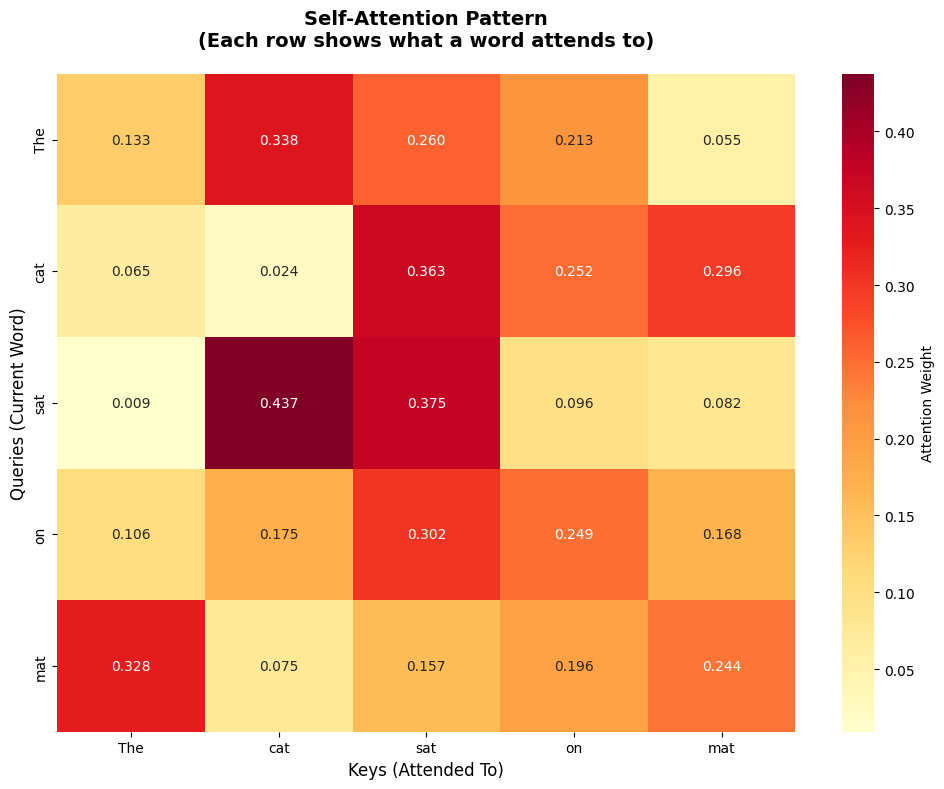


💡 Interpretation:
- Diagonal values: How much each word attends to itself
- Off-diagonal: Relationships between different words
- Bright cells: Strong attention (important relationships)
- Dark cells: Weak attention (less relevant)

✅ Exercise 1.2 Complete!


In [8]:
# ==================================================
# EXERCISE 1.2: VISUALIZING ATTENTION PATTERNS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.2: Attention Pattern Visualization")
print("=" * 80)

"""
📖 THEORY: Interpreting Attention Weights

Attention weights show which words the model focuses on when processing each word.
- High attention: Strong relationship between words
- Low attention: Words are less relevant to each other

In real applications:
- Can reveal syntactic relationships (subject-verb, adjective-noun)
- Can show semantic connections (pronoun resolution, co-reference)
- Helps debug model behavior and build trust
"""

print("\n📊 Creating attention visualization...")

# Create a more interpretable example with word tokens
words = ["The", "cat", "sat", "on", "mat"]
seq_len = len(words)

# Simulate attention pattern (cat attends to sat, sat attends to mat, etc.)
np.random.seed(42)
attention_pattern = np.random.rand(seq_len, seq_len)
# Normalize rows to sum to 1 (proper attention distribution)
attention_pattern = attention_pattern / attention_pattern.sum(axis=1, keepdims=True)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(attention_pattern, 
            annot=True, 
            fmt='.3f',
            cmap='YlOrRd',
            xticklabels=words,
            yticklabels=words,
            cbar_kws={'label': 'Attention Weight'})
plt.title('Self-Attention Pattern\n(Each row shows what a word attends to)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Keys (Attended To)', fontsize=12)
plt.ylabel('Queries (Current Word)', fontsize=12)
plt.tight_layout()

# Save plot
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/day50_attention_pattern.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day50_attention_pattern.png")
plt.show()

print("\n💡 Interpretation:")
print("- Diagonal values: How much each word attends to itself")
print("- Off-diagonal: Relationships between different words")
print("- Bright cells: Strong attention (important relationships)")
print("- Dark cells: Weak attention (less relevant)")

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)

In [10]:
# ==================================================
# EXERCISE 1.3: MULTI-HEAD ATTENTION DEEP DIVE
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.3: Why Multi-Head Attention?")
print("=" * 80)

"""
📖 THEORY: Multi-Head Attention

Instead of computing attention once, we compute it MULTIPLE times in parallel (multiple "heads").

Why Multiple Heads?
1. Different Representation Subspaces:
   - Head 1 might focus on syntactic relationships (subject-verb)
   - Head 2 might focus on semantic relationships (synonyms)
   - Head 3 might focus on positional relationships (adjacent words)

2. Increased Model Capacity:
   - Each head learns different patterns
   - Ensemble effect: combine multiple perspectives

3. Better Gradient Flow:
   - Multiple paths for gradient propagation
   - More stable training

Mathematical Process:
1. Split embedding into H heads: d_model → H × (d_model/H)
2. Apply self-attention independently for each head
3. Concatenate all head outputs
4. Apply final linear transformation

Example: BERT uses 12 heads with d_model=768
- Each head works with 768/12 = 64 dimensions
- All 12 heads process in parallel
- Final output: concatenated and projected back to 768 dims

Why this matters:
- Core innovation of "Attention is All You Need" paper
- Used in BERT, GPT, T5, and all modern transformers
- Provides rich, multi-faceted understanding of text
"""

print("\n📊 Comparing Single-Head vs Multi-Head Attention...")

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention with multiple parallel attention mechanisms
    """
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        
        assert (self.head_dim * heads == embed_size), "Embed size must be divisible by heads"
        
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)
        
    def forward(self, values, keys, query, mask=None):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        
        # Linear transformations
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)  # ✅ FIXED: changed from 'queries' to 'query'
        
        # Split into multiple heads
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        
        # Compute attention for all heads in parallel
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
            
        attention = torch.softmax(energy / (self.embed_size ** (1/2)), dim=3)
        
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        
        out = self.fc_out(out)
        return out, attention

print("✅ Multi-Head Attention class implemented!")

# Compare different numbers of heads
print("\n⏱ Testing with different numbers of attention heads...")

embed_size = 512
seq_len = 10
batch_size = 2
sample_input = torch.randn(batch_size, seq_len, embed_size)

head_configs = [1, 4, 8, 16]
results = []

for num_heads in head_configs:
    mha = MultiHeadAttention(embed_size, heads=num_heads)
    output, attention_weights = mha(sample_input, sample_input, sample_input)
    
    results.append({
        'heads': num_heads,
        'head_dim': embed_size // num_heads,
        'attention_shape': attention_weights.shape,
        'output_shape': output.shape
    })
    
    print(f"\n📊 Configuration: {num_heads} heads")
    print(f"   ├─ Head dimension: {embed_size // num_heads}")
    print(f"   ├─ Attention shape: {attention_weights.shape}")
    print(f"   └─ Output shape: {output.shape}")

print("\n💡 Key Observations:")
print("1. More heads = smaller dimension per head")
print("2. All configurations produce same output shape (embed_size)")
print("3. Each head learns different attention patterns")
print("4. BERT uses 12 heads, GPT-3 uses 96 heads!")

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)


EXERCISE 1.3: Why Multi-Head Attention?

📊 Comparing Single-Head vs Multi-Head Attention...
✅ Multi-Head Attention class implemented!

⏱ Testing with different numbers of attention heads...

📊 Configuration: 1 heads
   ├─ Head dimension: 512
   ├─ Attention shape: torch.Size([2, 1, 10, 10])
   └─ Output shape: torch.Size([2, 10, 512])

📊 Configuration: 4 heads
   ├─ Head dimension: 128
   ├─ Attention shape: torch.Size([2, 4, 10, 10])
   └─ Output shape: torch.Size([2, 10, 512])

📊 Configuration: 8 heads
   ├─ Head dimension: 64
   ├─ Attention shape: torch.Size([2, 8, 10, 10])
   └─ Output shape: torch.Size([2, 10, 512])

📊 Configuration: 16 heads
   ├─ Head dimension: 32
   ├─ Attention shape: torch.Size([2, 16, 10, 10])
   └─ Output shape: torch.Size([2, 10, 512])

💡 Key Observations:
1. More heads = smaller dimension per head
2. All configurations produce same output shape (embed_size)
3. Each head learns different attention patterns
4. BERT uses 12 heads, GPT-3 uses 96 heads!

✅ 


EXERCISE 1.4: Positional Encoding for Sequence Order

📊 Implementing Sinusoidal Positional Encoding...
✅ Positional encoding shape: (100, 512)
   └─ (sequence_length=100, embedding_dim=512)

📊 Visualizing positional encoding patterns...
✅ Saved: results/plots/day50_positional_encoding.png


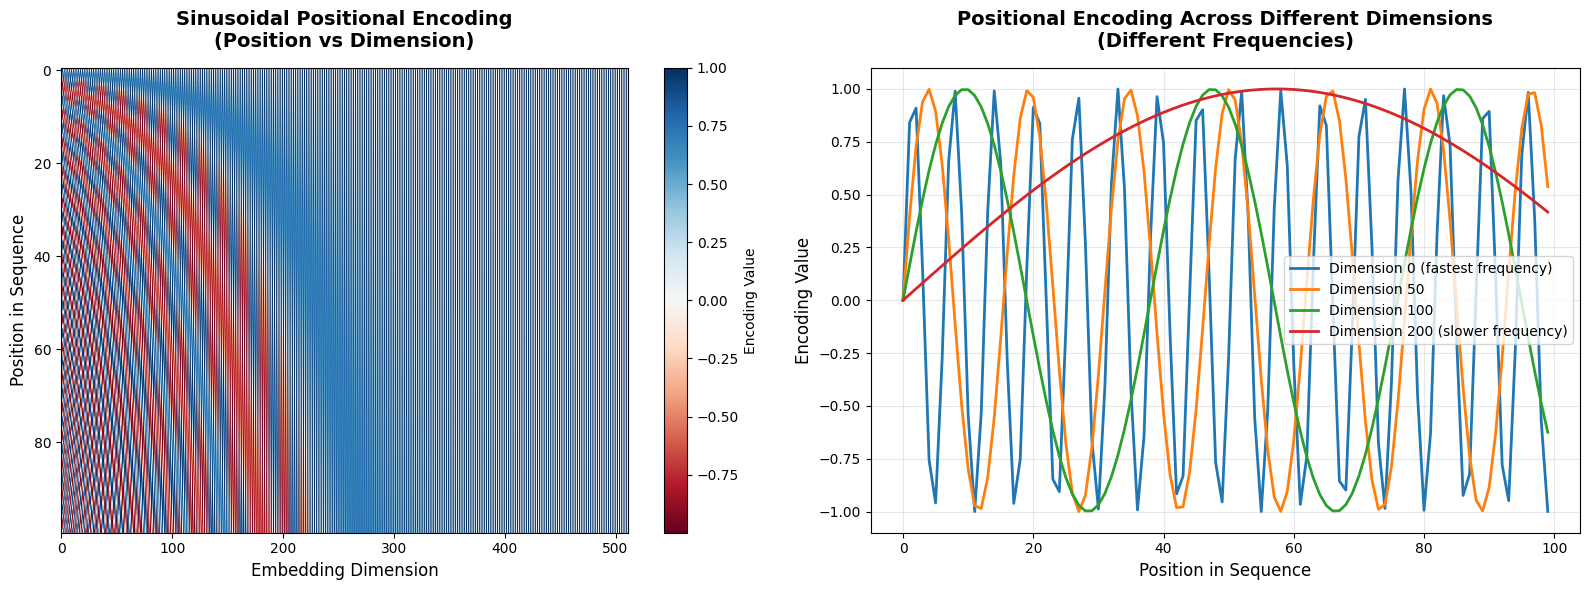


💡 Key Insights:
1. Lower dimensions oscillate faster (capture local patterns)
2. Higher dimensions oscillate slower (capture global patterns)
3. Each position gets unique encoding across all dimensions
4. Smooth transitions between positions (no discontinuities)

✅ Exercise 1.4 Complete!


In [11]:
# ==================================================
# EXERCISE 1.4: POSITIONAL ENCODING
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.4: Positional Encoding for Sequence Order")
print("=" * 80)

"""
📖 THEORY: Positional Encoding

Problem: Self-attention has NO notion of word order!
- "dog bites man" and "man bites dog" would have identical representations
- RNNs/LSTMs naturally encode position through sequential processing
- Transformers process all positions in parallel → need explicit position info

Solution: Add positional encoding to input embeddings

Two approaches:
1. Learned Positional Embeddings (BERT):
   - Treat positions as learnable parameters
   - Model learns optimal position representations during training

2. Sinusoidal Positional Encoding (Original Transformer):
   - PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
   - PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
   - Fixed function, no learning required
   - Can extrapolate to longer sequences

Why sinusoidal functions?
- Different frequencies for different dimensions
- Allows model to attend by relative positions
- Smooth representation of position

Why this matters:
- Critical for maintaining sequence order information
- Without it, "I love dogs" = "dogs love I"
- BERT's success partly due to learned positional embeddings up to 512 tokens
"""

print("\n📊 Implementing Sinusoidal Positional Encoding...")

def get_positional_encoding(seq_len, d_model):
    """
    Generate sinusoidal positional encoding
    
    Args:
        seq_len: Maximum sequence length
        d_model: Dimension of embeddings
        
    Returns:
        Positional encoding matrix of shape (seq_len, d_model)
    """
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(position * div_term)
    pos_encoding[:, 1::2] = np.cos(position * div_term)
    
    return pos_encoding

# Generate positional encoding
seq_len = 100
d_model = 512
pos_encoding = get_positional_encoding(seq_len, d_model)

print(f"✅ Positional encoding shape: {pos_encoding.shape}")
print(f"   └─ (sequence_length={seq_len}, embedding_dim={d_model})")

# Visualize positional encoding
print("\n📊 Visualizing positional encoding patterns...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full positional encoding heatmap
im1 = ax1.imshow(pos_encoding, cmap='RdBu', aspect='auto')
ax1.set_title('Sinusoidal Positional Encoding\n(Position vs Dimension)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Embedding Dimension', fontsize=12)
ax1.set_ylabel('Position in Sequence', fontsize=12)
plt.colorbar(im1, ax=ax1, label='Encoding Value')

# Plot 2: Positional encoding for specific dimensions
ax2.plot(pos_encoding[:, 0], label='Dimension 0 (fastest frequency)', linewidth=2)
ax2.plot(pos_encoding[:, 50], label='Dimension 50', linewidth=2)
ax2.plot(pos_encoding[:, 100], label='Dimension 100', linewidth=2)
ax2.plot(pos_encoding[:, 200], label='Dimension 200 (slower frequency)', linewidth=2)
ax2.set_title('Positional Encoding Across Different Dimensions\n(Different Frequencies)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Position in Sequence', fontsize=12)
ax2.set_ylabel('Encoding Value', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/day50_positional_encoding.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day50_positional_encoding.png")
plt.show()

print("\n💡 Key Insights:")
print("1. Lower dimensions oscillate faster (capture local patterns)")
print("2. Higher dimensions oscillate slower (capture global patterns)")
print("3. Each position gets unique encoding across all dimensions")
print("4. Smooth transitions between positions (no discontinuities)")

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)

In [12]:
print("\n" + "=" * 80)
print("📊 PART 2: BERT ARCHITECTURE & PRE-TRAINING")
print("=" * 80)


📊 PART 2: BERT ARCHITECTURE & PRE-TRAINING



EXERCISE 2.1: Understanding BERT Architecture

📊 Visualizing BERT Architecture...
✅ Saved: results/plots/day50_bert_architecture.png


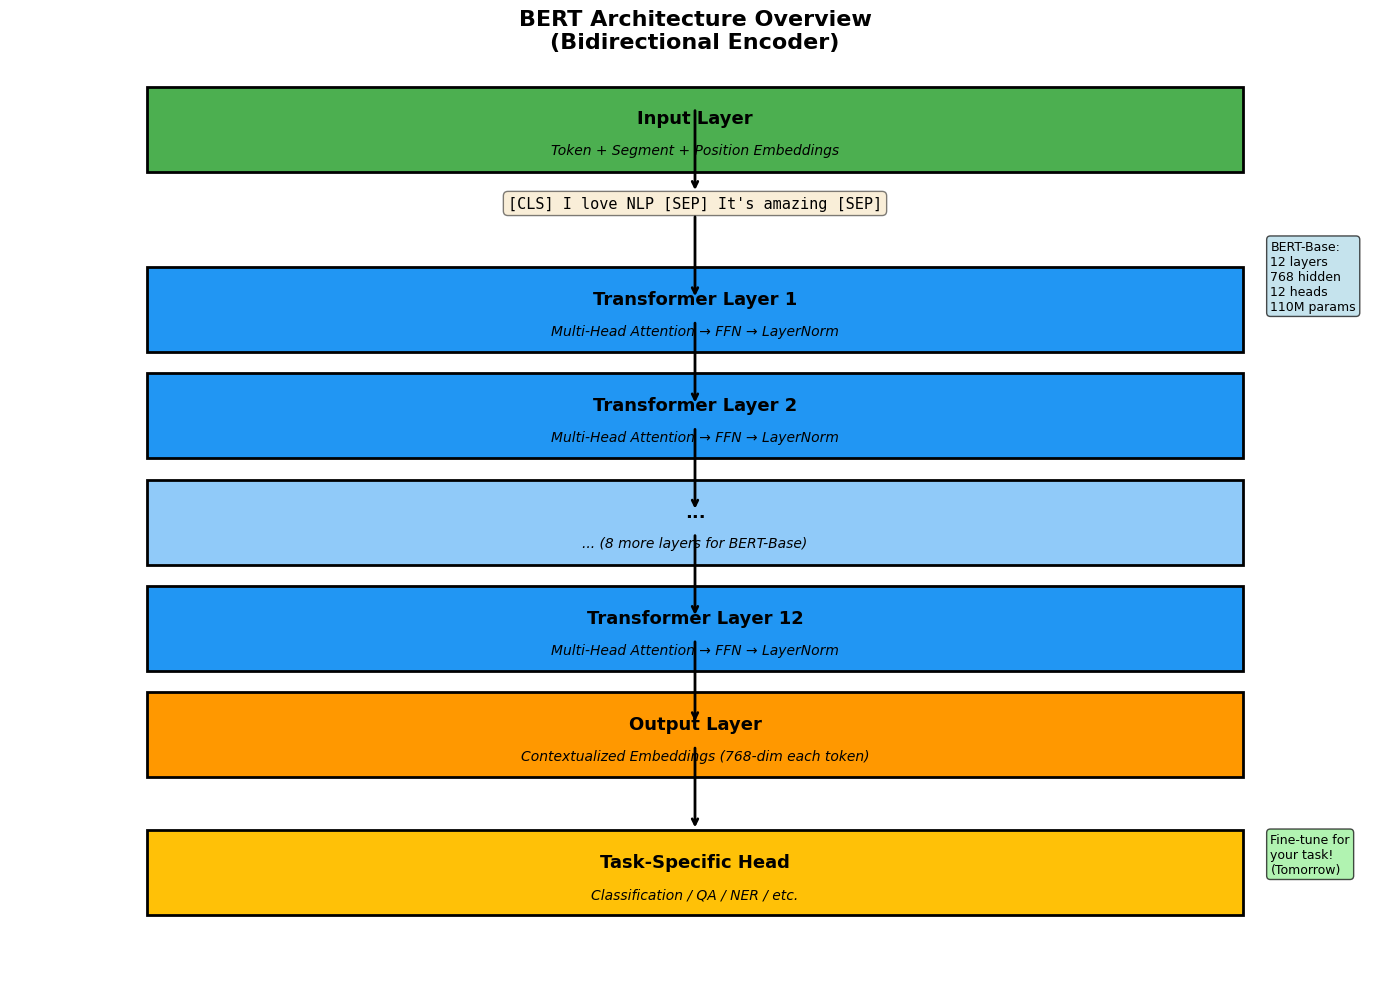


💡 Key Architectural Features:
1. Bidirectional: Sees full context (left + right)
2. Deep: 12-24 transformer layers for rich representations
3. Transfer Learning: Pre-train once, fine-tune for any task
4. Attention: 12-16 heads capture multiple relationships

✅ Exercise 2.1 Complete!


In [13]:
# ==================================================
# EXERCISE 2.1: BERT ARCHITECTURE OVERVIEW
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.1: Understanding BERT Architecture")
print("=" * 80)

"""
📖 THEORY: BERT (Bidirectional Encoder Representations from Transformers)

BERT revolutionized NLP in 2018 by introducing bidirectional pre-training.

Key Innovation: Bidirectional Context
- Traditional models (like GPT): Read text left-to-right (unidirectional)
- BERT: Reads text in BOTH directions simultaneously
- Example: "The bank of the river"
  - Unidirectional: "bank" only sees "The" (could be financial bank)
  - BERT: "bank" sees both "The" and "of the river" (understands it's riverbank)

BERT Architecture Components:
1. **Input Embeddings** (3 types combined):
   - Token Embeddings: Word piece tokens (30,000 vocabulary)
   - Segment Embeddings: Distinguish sentence A from sentence B
   - Position Embeddings: Learned positions (up to 512 tokens)

2. **Transformer Encoder Layers** (stacked):
   - BERT-Base: 12 layers, 768 hidden size, 12 attention heads
   - BERT-Large: 24 layers, 1024 hidden size, 16 attention heads
   - Each layer: Multi-head attention → Feed-forward → Layer norm

3. **Special Tokens**:
   - [CLS]: Classification token (always first, used for sentence-level tasks)
   - [SEP]: Separator between sentences
   - [MASK]: Masked token for training
   - [PAD]: Padding for batch processing

Model Sizes:
- BERT-Base: 110M parameters
- BERT-Large: 340M parameters

Why this matters:
- Foundation for modern NLP (RoBERTa, ALBERT, DistilBERT all based on BERT)
- Can be fine-tuned for ANY downstream task
- State-of-the-art on 11 NLP tasks when released
- Your Week 7 LSTM (2.2M params) vs BERT-Base (110M params) - 50x larger!
"""

print("\n📊 Visualizing BERT Architecture...")

# Create architecture visualization
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

# Define architecture layers
layers = [
    ("Input Layer", "Token + Segment + Position Embeddings", 0.95),
    ("", "[CLS] I love NLP [SEP] It's amazing [SEP]", 0.88),
    ("Transformer Layer 1", "Multi-Head Attention → FFN → LayerNorm", 0.78),
    ("Transformer Layer 2", "Multi-Head Attention → FFN → LayerNorm", 0.68),
    ("...", "... (8 more layers for BERT-Base)", 0.58),
    ("Transformer Layer 12", "Multi-Head Attention → FFN → LayerNorm", 0.48),
    ("Output Layer", "Contextualized Embeddings (768-dim each token)", 0.38),
    ("Task-Specific Head", "Classification / QA / NER / etc.", 0.25),
]

colors = ['#4CAF50', '#E8F5E9', '#2196F3', '#2196F3', '#90CAF9', '#2196F3', '#FF9800', '#FFC107']

for i, (title, desc, y_pos) in enumerate(layers):
    if title:  # Skip empty titles
        # Draw box
        rect = plt.Rectangle((0.1, y_pos-0.04), 0.8, 0.08, 
                            facecolor=colors[i], edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        
        # Add text
        ax.text(0.5, y_pos+0.01, title, ha='center', va='center', 
               fontsize=13, fontweight='bold')
        ax.text(0.5, y_pos-0.02, desc, ha='center', va='center', 
               fontsize=10, style='italic')
    else:
        # Just text for input example
        ax.text(0.5, y_pos, desc, ha='center', va='center', 
               fontsize=11, family='monospace', 
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add arrows
arrow_positions = [0.91, 0.81, 0.71, 0.61, 0.51, 0.41, 0.31]
for y in arrow_positions:
    ax.annotate('', xy=(0.5, y-0.02), xytext=(0.5, y+0.06),
               arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add side annotations
ax.text(0.92, 0.78, 'BERT-Base:\n12 layers\n768 hidden\n12 heads\n110M params', 
       fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax.text(0.92, 0.25, 'Fine-tune for\nyour task!\n(Tomorrow)', 
       fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.title('BERT Architecture Overview\n(Bidirectional Encoder)', 
         fontsize=16, fontweight='bold', pad=20)
plt.xlim(0, 1)
plt.ylim(0.15, 1)

plt.tight_layout()
plt.savefig('results/plots/day50_bert_architecture.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day50_bert_architecture.png")
plt.show()

print("\n💡 Key Architectural Features:")
print("1. Bidirectional: Sees full context (left + right)")
print("2. Deep: 12-24 transformer layers for rich representations")
print("3. Transfer Learning: Pre-train once, fine-tune for any task")
print("4. Attention: 12-16 heads capture multiple relationships")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)

In [14]:
# ==================================================
# EXERCISE 2.2: BERT PRE-TRAINING OBJECTIVES
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.2: How BERT is Pre-trained")
print("=" * 80)

"""
📖 THEORY: BERT Pre-training Tasks

BERT learns language understanding through TWO self-supervised tasks:

1. MASKED LANGUAGE MODEL (MLM) - Main Task
   How it works:
   - Randomly mask 15% of input tokens
   - Model predicts the masked words using bidirectional context
   
   Example:
   Input:  "The [MASK] sat on the mat"
   Target: "cat"
   Context: Model sees "The __ sat on the mat" and predicts "cat"
   
   Masking strategy (for each 15% selected):
   - 80% replace with [MASK]: "The [MASK] sat..."
   - 10% replace with random word: "The apple sat..."
   - 10% keep unchanged: "The cat sat..."
   
   Why this is brilliant:
   - Forces model to understand context deeply
   - Can't just memorize [MASK] → word mappings
   - Learns bidirectional representations naturally

2. NEXT SENTENCE PREDICTION (NSP) - Secondary Task
   How it works:
   - Given two sentences A and B
   - Predict if B actually follows A in original text
   
   Example:
   Input A: "I love machine learning"
   Input B: "It's fascinating to build models"
   Label: IsNext (True)
   
   Input A: "I love machine learning"
   Input B: "The sky is blue today"
   Label: NotNext (False)
   
   Why useful:
   - Helps with sentence-pair tasks (QA, NLI)
   - Understands sentence relationships
   - Note: Some newer models (RoBERTa) drop NSP as less important

Pre-training Data:
- BooksCorpus: 800M words
- English Wikipedia: 2,500M words
- Total: 3.3 billion words!
- Training time: 4 days on 64 TPU chips (Google's specialized hardware)

Why this matters:
- Self-supervised: No manual labels needed!
- Learns general language understanding
- Transfer learning: Use pre-trained model, fine-tune for specific task
- You get a "language expert" without training from scratch
"""

print("\n📊 Simulating MLM Task...")

# Example sentences
sentences = [
    "The quick brown fox jumps over the lazy dog",
    "Machine learning transforms how we process data",
    "BERT uses bidirectional context for understanding",
    "Transformers revolutionized natural language processing"
]

print("\n🎯 Masked Language Model Examples:\n")

np.random.seed(42)
for i, sentence in enumerate(sentences, 1):
    words = sentence.split()
    
    # Randomly mask 15% of words (at least 1)
    num_masks = max(1, int(len(words) * 0.15))
    mask_indices = np.random.choice(len(words), num_masks, replace=False)
    
    masked_sentence = words.copy()
    original_words = []
    
    for idx in mask_indices:
        original_words.append((idx, words[idx]))
        masked_sentence[idx] = "[MASK]"
    
    print(f"Example {i}:")
    print(f"  Original:  {sentence}")
    print(f"  Masked:    {' '.join(masked_sentence)}")
    print(f"  Targets:   ", end="")
    for idx, word in original_words:
        print(f"Position {idx}='{word}'", end=" ")
    print("\n")

print("\n📊 Simulating NSP Task...\n")

sentence_pairs = [
    {
        'A': "BERT was released by Google in 2018",
        'B': "It achieved state-of-the-art results on many tasks",
        'label': 'IsNext',
        'reason': 'B continues the topic from A'
    },
    {
        'A': "BERT was released by Google in 2018",
        'B': "The weather is nice today",
        'label': 'NotNext',
        'reason': 'B is unrelated to A'
    },
    {
        'A': "Self-attention allows the model to focus on relevant words",
        'B': "This mechanism is key to transformer performance",
        'label': 'IsNext',
        'reason': 'B explains the importance of A'
    },
    {
        'A': "Self-attention allows the model to focus on relevant words",
        'B': "Pizza is a popular Italian dish",
        'label': 'NotNext',
        'reason': 'Completely different topic'
    }
]

print("🎯 Next Sentence Prediction Examples:\n")

for i, pair in enumerate(sentence_pairs, 1):
    print(f"Example {i}:")
    print(f"  Sentence A: {pair['A']}")
    print(f"  Sentence B: {pair['B']}")
    print(f"  Label:      {pair['label']}")
    print(f"  Reason:     {pair['reason']}")
    print()

print("\n💡 Pre-training Statistics:")
print("=" * 60)
print(f"{'Metric':<30} {'Value':<30}")
print("=" * 60)
print(f"{'Training Data':<30} {'3.3 billion words':<30}")
print(f"{'Training Time (BERT-Base)':<30} {'4 days on 64 TPUs':<30}")
print(f"{'MLM Mask Rate':<30} {'15% of tokens':<30}")
print(f"{'NSP Ratio':<30} {'50% IsNext, 50% NotNext':<30}")
print(f"{'Vocabulary Size':<30} {'30,000 WordPieces':<30}")
print(f"{'Max Sequence Length':<30} {'512 tokens':<30}")
print("=" * 60)

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)


EXERCISE 2.2: How BERT is Pre-trained

📊 Simulating MLM Task...

🎯 Masked Language Model Examples:

Example 1:
  Original:  The quick brown fox jumps over the lazy dog
  Masked:    The quick brown fox jumps over the [MASK] dog
  Targets:   Position 7='lazy' 

Example 2:
  Original:  Machine learning transforms how we process data
  Masked:    Machine learning transforms how [MASK] process data
  Targets:   Position 4='we' 

Example 3:
  Original:  BERT uses bidirectional context for understanding
  Masked:    [MASK] uses bidirectional context for understanding
  Targets:   Position 0='BERT' 

Example 4:
  Original:  Transformers revolutionized natural language processing
  Masked:    Transformers revolutionized natural language [MASK]
  Targets:   Position 4='processing' 


📊 Simulating NSP Task...

🎯 Next Sentence Prediction Examples:

Example 1:
  Sentence A: BERT was released by Google in 2018
  Sentence B: It achieved state-of-the-art results on many tasks
  Label:      IsNext
  R

In [16]:
# ==================================================
# EXERCISE 2.3: BERT TOKENIZATION & WORDPIECE
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.3: BERT Tokenization with WordPiece")
print("=" * 80)

"""
📖 THEORY: WordPiece Tokenization

BERT doesn't tokenize at word level - it uses WordPiece tokenization!

Why WordPiece?
1. Handles unknown words gracefully
2. Reduces vocabulary size (30K vs 100K+ for full words)
3. Captures morphology (word structure)

How it works:
- Common words: Kept whole ("the", "is", "learning")
- Rare words: Split into subwords ("playing" → "play" + "##ing")
- Unknown words: Split into characters if needed

Example: "unhappiness"
- Word-level: 1 token (if in vocabulary, otherwise [UNK])
- WordPiece: "un" + "##hap" + "##pi" + "##ness" (captures morphology!)

Special Tokens:
- [CLS]: Start of sequence (used for classification)
- [SEP]: Separator between sentences
- [PAD]: Padding to make sequences same length
- [MASK]: Masked token for MLM training
- [UNK]: Unknown token (rare with WordPiece)

Token IDs:
- Each token maps to an integer ID (0-30,521 for BERT)
- Model processes IDs, not raw text

Why this matters:
- Robust to typos and rare words
- Efficient vocabulary usage
- Better than character-level (too granular) or word-level (too many unknowns)
- Critical for BERT's success on diverse tasks
"""

print("\n⏱ Loading BERT tokenizer...")

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("✅ Tokenizer loaded!")
print(f"   ├─ Vocabulary size: {len(tokenizer)}")
print(f"   └─ Model: bert-base-uncased (lowercase)")

# Test sentences
test_sentences = [
    "Hello, how are you?",
    "Machine learning is fascinating!",
    "BERT uses WordPiece tokenization",
    "Supercalifragilisticexpialidocious",  # Very rare word
    "The quick brown fox jumps",
    "Natural Language Processing in 2024"
]

print("\n" + "=" * 80)
print("📊 TOKENIZATION EXAMPLES")
print("=" * 80)

for i, sentence in enumerate(test_sentences, 1):
    print(f"\nExample {i}: \"{sentence}\"")
    print("-" * 80)
    
    # Tokenize
    tokens = tokenizer.tokenize(sentence)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    
    # Show tokens
    print(f"Tokens ({len(tokens)}): {tokens}")
    print(f"Token IDs: {token_ids}")
    
    # Highlight subword tokens (those starting with ##)
    subword_tokens = [t for t in tokens if t.startswith('##')]
    if subword_tokens:
        print(f"⚠️  Subword tokens found: {subword_tokens}")
        print(f"   └─ This word was split into pieces!")

# Demonstrate full encoding (with special tokens)
print("\n" + "=" * 80)
print("📊 FULL ENCODING WITH SPECIAL TOKENS")
print("=" * 80)

sentence1 = "I love BERT"
sentence2 = "It's amazing for NLP"

# Encode as sentence pair
encoding = tokenizer(
    sentence1, 
    sentence2,
    add_special_tokens=True,
    padding='max_length',
    max_length=20,
    truncation=True,
    return_tensors='pt'
)

print(f"\nSentence A: \"{sentence1}\"")
print(f"Sentence B: \"{sentence2}\"")
print(f"\nEncoded format:")
print(f"  [CLS] {sentence1} [SEP] {sentence2} [SEP] [PAD]...\n")

# Decode to see actual tokens
tokens_decoded = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
print(f"Tokens: {tokens_decoded}\n")

print(f"Input IDs shape: {encoding['input_ids'].shape}")
print(f"Input IDs: {encoding['input_ids'][0].tolist()}\n")

print(f"Attention Mask: {encoding['attention_mask'][0].tolist()}")
print(f"  └─ 1 = real token, 0 = padding\n")

print(f"Token Type IDs: {encoding['token_type_ids'][0].tolist()}")
print(f"  └─ 0 = sentence A, 1 = sentence B")

# Vocabulary exploration
print("\n" + "=" * 80)
print("📊 VOCABULARY EXPLORATION")
print("=" * 80)

special_tokens = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
print(f"\n🎯 Special Tokens:")
for token in special_tokens:
    token_id = tokenizer.convert_tokens_to_ids(token)
    print(f"  {token:<10} → ID: {token_id}")

# Show some common tokens
common_words = ['the', 'is', 'a', 'to', 'and', 'of', 'in']
print(f"\n🎯 Common Words:")
for word in common_words:
    tokens = tokenizer.tokenize(word)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    print(f"  {word} → {tokens} → {token_ids}")

# Show subword splitting
print(f"\n🎯 Subword Splitting Examples:")
words_with_subwords = ['unhappiness', 'preprocessing', 'transformer', 'tokenization']
for word in words_with_subwords:
    tokens = tokenizer.tokenize(word)
    print(f"  {word} → {tokens}")

print("\n💡 Key Insights:")
print("1. Common words = single token (efficient)")
print("2. Rare words = split into subwords (no [UNK]!)")
print("3. Special tokens have reserved IDs (0-999)")
print("4. Subwords start with ## to indicate continuation")
print("5. Max 512 tokens per input (BERT limitation)")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: BERT Tokenization with WordPiece

⏱ Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\audrey\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

✅ Tokenizer loaded!
   ├─ Vocabulary size: 30522
   └─ Model: bert-base-uncased (lowercase)

📊 TOKENIZATION EXAMPLES

Example 1: "Hello, how are you?"
--------------------------------------------------------------------------------
Tokens (6): ['hello', ',', 'how', 'are', 'you', '?']
Token IDs: [7592, 1010, 2129, 2024, 2017, 1029]

Example 2: "Machine learning is fascinating!"
--------------------------------------------------------------------------------
Tokens (5): ['machine', 'learning', 'is', 'fascinating', '!']
Token IDs: [3698, 4083, 2003, 17160, 999]

Example 3: "BERT uses WordPiece tokenization"
--------------------------------------------------------------------------------
Tokens (6): ['bert', 'uses', 'word', '##piece', 'token', '##ization']
Token IDs: [14324, 3594, 2773, 11198, 19204, 3989]
⚠️  Subword tokens found: ['##piece', '##ization']
   └─ This word was split into pieces!

Example 4: "Supercalifragilisticexpialidocious"
-----------------------------------------------

In [17]:
print("\n" + "=" * 80)
print("🤗 PART 3: HUGGING FACE TRANSFORMERS - HANDS-ON")
print("=" * 80)


🤗 PART 3: HUGGING FACE TRANSFORMERS - HANDS-ON


In [19]:
# ==================================================
# EXERCISE 3.1: LOADING PRE-TRAINED BERT MODEL
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.1: Loading and Exploring Pre-trained BERT")
print("=" * 80)

"""
📖 THEORY: Using Pre-trained BERT

Hugging Face Transformers library makes it incredibly easy to use BERT!

Available BERT Models:
1. bert-base-uncased: 12 layers, 768 hidden, 110M params (lowercase)
2. bert-large-uncased: 24 layers, 1024 hidden, 340M params (lowercase)
3. bert-base-cased: Same as base but preserves case
4. bert-base-multilingual: Supports 104 languages!

What we get:
- Pre-trained weights (trained on 3.3B words)
- Ready for fine-tuning on your task
- Can use directly for feature extraction

Model Components:
1. BertModel: Raw transformer outputs (embeddings)
2. BertForSequenceClassification: + classification head
3. BertForQuestionAnswering: + QA head
4. BertForTokenClassification: + NER head

Why this matters:
- No need to train from scratch (saves weeks of compute time!)
- Transfer learning: Leverage Google's training effort
- Just fine-tune on your specific task (tomorrow!)
- State-of-the-art results with minimal data
"""

print("\n⏱ Loading BERT model (this may take 30-60 seconds)...")
print("   Downloading ~440MB of pre-trained weights...\n")

# Load pre-trained BERT model
model = BertModel.from_pretrained('bert-base-uncased')
config = BertConfig.from_pretrained('bert-base-uncased')

print("✅ BERT model loaded successfully!\n")

# Display model configuration
print("=" * 80)
print("📊 MODEL CONFIGURATION")
print("=" * 80)

config_info = {
    "Model Name": "bert-base-uncased",
    "Hidden Size": config.hidden_size,
    "Number of Layers": config.num_hidden_layers,
    "Attention Heads": config.num_attention_heads,
    "Intermediate Size": config.intermediate_size,
    "Max Position Embeddings": config.max_position_embeddings,
    "Vocabulary Size": config.vocab_size,
    "Hidden Dropout": config.hidden_dropout_prob,
    "Attention Dropout": config.attention_probs_dropout_prob,
}

for key, value in config_info.items():
    print(f"  {key:<25} : {value}")

# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n  {'Total Parameters':<25} : {total_params:,}")
print(f"  {'Trainable Parameters':<25} : {trainable_params:,}")
print(f"  {'Model Size (MB)':<25} : {total_params * 4 / (1024**2):.2f}")

print("\n💡 Architecture Breakdown:")
print(f"  • Each attention head: {config.hidden_size // config.num_attention_heads} dimensions")
print(f"  • Feed-forward intermediate: {config.intermediate_size} dimensions")
print(f"  • Total transformer blocks: {config.num_hidden_layers}")

# Compare with Week 7 LSTM
print("\n📊 Comparison with Week 7 LSTM:")
print("=" * 80)
print(f"  {'Model':<20} {'Parameters':<20} {'Layers':<15}")
print("=" * 80)
print(f"  {'Week 7 LSTM':<20} {'2.2M':<20} {'2 LSTM layers':<15}")
print(f"  {'BERT-Base':<20} {f'{total_params/1e6:.1f}M':<20} {'12 Transformers':<15}")
print(f"  {'Difference':<20} {f'{total_params/2.2e6:.1f}x larger':<20} {'6x deeper':<15}")
print("=" * 80)

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Loading and Exploring Pre-trained BERT

⏱ Loading BERT model (this may take 30-60 seconds)...

✅ BERT model loaded successfully!

📊 MODEL CONFIGURATION
  Model Name                : bert-base-uncased
  Hidden Size               : 768
  Number of Layers          : 12
  Attention Heads           : 12
  Intermediate Size         : 3072
  Max Position Embeddings   : 512
  Vocabulary Size           : 30522
  Hidden Dropout            : 0.1
  Attention Dropout         : 0.1

  Total Parameters          : 109,482,240
  Trainable Parameters      : 109,482,240
  Model Size (MB)           : 417.64

💡 Architecture Breakdown:
  • Each attention head: 64 dimensions
  • Feed-forward intermediate: 3072 dimensions
  • Total transformer blocks: 12

📊 Comparison with Week 7 LSTM:
  Model                Parameters           Layers         
  Week 7 LSTM          2.2M                 2 LSTM layers  
  BERT-Base            109.5M               12 Transformers
  Difference           49.8x lar


EXERCISE 3.2: Understanding BERT Embeddings

⏱ Extracting embeddings from sample sentences...

📊 Test Sentences:
  1. The bank is next to the river.
  2. I need to go to the bank to withdraw money.
  3. The company will bank on their new product.

⏱ Processing through BERT...

Sentence 1:
  Tokens: ['[CLS]', 'the', 'bank', 'is', 'next', 'to', 'the', 'river', '.', '[SEP]']
  Shape: torch.Size([1, 10, 768]) → (batch=1, tokens=10, embedding=768)
  [CLS] embedding shape: torch.Size([1, 768])

Sentence 2:
  Tokens: ['[CLS]', 'i', 'need', 'to', 'go', 'to', 'the', 'bank', 'to', 'withdraw', 'money', '.', '[SEP]']
  Shape: torch.Size([1, 13, 768]) → (batch=1, tokens=13, embedding=768)
  [CLS] embedding shape: torch.Size([1, 768])

Sentence 3:
  Tokens: ['[CLS]', 'the', 'company', 'will', 'bank', 'on', 'their', 'new', 'product', '.', '[SEP]']
  Shape: torch.Size([1, 11, 768]) → (batch=1, tokens=11, embedding=768)
  [CLS] embedding shape: torch.Size([1, 768])

📊 CONTEXTUALIZED EMBEDDINGS: Word '

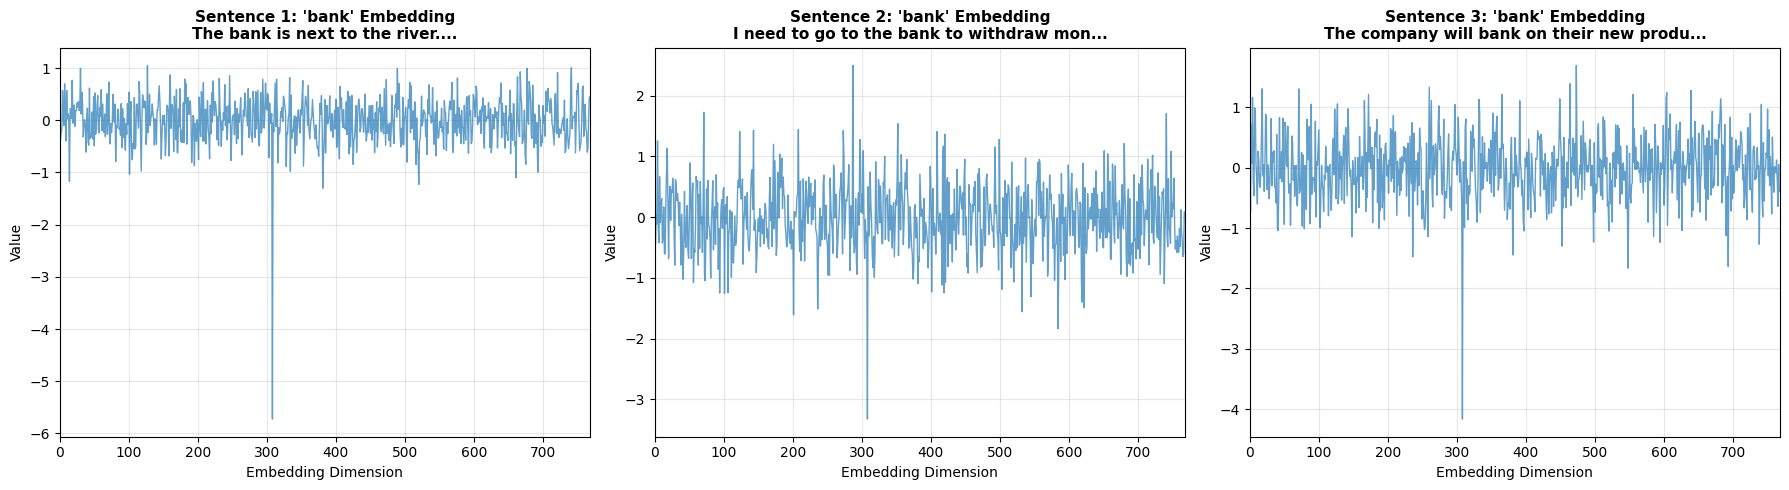


✅ Exercise 3.2 Complete!


In [20]:
# ==================================================
# EXERCISE 3.2: EXTRACTING BERT EMBEDDINGS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.2: Understanding BERT Embeddings")
print("=" * 80)

"""
📖 THEORY: BERT Embeddings

BERT produces contextualized embeddings - each word's representation 
depends on its context (surrounding words).

Embedding Types:
1. Input Embeddings: Token + Position + Segment (before transformer)
2. Hidden States: Outputs from each transformer layer
3. Final Embeddings: Output from last layer (most commonly used)

Key Difference from Word2Vec/GloVe:
- Word2Vec: "bank" always has same embedding
- BERT: "bank" has different embeddings:
  - "bank account" → financial institution
  - "river bank" → land beside water

Model Outputs:
- last_hidden_state: Final layer embeddings [batch, seq_len, 768]
- pooler_output: [CLS] token processed [batch, 768]
- hidden_states: All layer outputs (if output_hidden_states=True)
- attentions: Attention weights (if output_attentions=True)

Why this matters:
- Contextualized = understands word meaning from context
- Can be used as features for downstream tasks
- Tomorrow we'll add a classifier on top of these embeddings
"""

print("\n⏱ Extracting embeddings from sample sentences...\n")

# Sample sentences with same word in different contexts
sentences = [
    "The bank is next to the river.",
    "I need to go to the bank to withdraw money.",
    "The company will bank on their new product.",
]

print("📊 Test Sentences:")
for i, sent in enumerate(sentences, 1):
    print(f"  {i}. {sent}")

# Tokenize and get embeddings
print("\n⏱ Processing through BERT...\n")

model.eval()  # Set to evaluation mode
embeddings_list = []

with torch.no_grad():  # No gradient computation needed
    for i, sentence in enumerate(sentences, 1):
        # Tokenize
        inputs = tokenizer(sentence, return_tensors='pt', padding=True, truncation=True)
        
        # Get BERT outputs
        outputs = model(**inputs)
        
        # Extract embeddings
        last_hidden_states = outputs.last_hidden_state  # [1, seq_len, 768]
        pooler_output = outputs.pooler_output  # [1, 768]
        
        embeddings_list.append({
            'sentence': sentence,
            'tokens': tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]),
            'last_hidden_states': last_hidden_states,
            'pooler_output': pooler_output
        })
        
        print(f"Sentence {i}:")
        print(f"  Tokens: {embeddings_list[-1]['tokens']}")
        print(f"  Shape: {last_hidden_states.shape} → (batch=1, tokens={last_hidden_states.shape[1]}, embedding=768)")
        print(f"  [CLS] embedding shape: {pooler_output.shape}\n")

# Analyze "bank" embeddings in different contexts
print("=" * 80)
print("📊 CONTEXTUALIZED EMBEDDINGS: Word 'bank' in Different Contexts")
print("=" * 80)

# Find "bank" token position in each sentence
bank_embeddings = []

for i, item in enumerate(embeddings_list):
    tokens = item['tokens']
    if 'bank' in tokens:
        bank_idx = tokens.index('bank')
        bank_embedding = item['last_hidden_states'][0, bank_idx, :].numpy()
        bank_embeddings.append(bank_embedding)
        
        print(f"\nSentence {i+1}: \"{item['sentence']}\"")
        print(f"  'bank' at position {bank_idx}")
        print(f"  Embedding shape: {bank_embedding.shape}")
        print(f"  First 10 values: {bank_embedding[:10]}")

# Calculate similarity between "bank" embeddings
print("\n" + "=" * 80)
print("📊 SIMILARITY ANALYSIS")
print("=" * 80)

from sklearn.metrics.pairwise import cosine_similarity

if len(bank_embeddings) >= 2:
    sim_1_2 = cosine_similarity([bank_embeddings[0]], [bank_embeddings[1]])[0][0]
    sim_1_3 = cosine_similarity([bank_embeddings[0]], [bank_embeddings[2]])[0][0]
    sim_2_3 = cosine_similarity([bank_embeddings[1]], [bank_embeddings[2]])[0][0]
    
    print("\nCosine Similarity between 'bank' embeddings:")
    print(f"  Sentence 1 vs 2 (river vs money):    {sim_1_2:.4f}")
    print(f"  Sentence 1 vs 3 (river vs rely on):  {sim_1_3:.4f}")
    print(f"  Sentence 2 vs 3 (money vs rely on):  {sim_2_3:.4f}")
    
    print("\n💡 Insights:")
    print("  • Different contexts → different embeddings!")
    print("  • Financial senses (2 & 3) more similar than river sense (1)")
    print("  • This is the power of contextualized embeddings")

# Visualize embedding dimensions
print("\n⏱ Creating embedding visualization...\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ax, emb) in enumerate(zip(axes, bank_embeddings)):
    ax.plot(emb, linewidth=1, alpha=0.7)
    ax.set_title(f"Sentence {i+1}: 'bank' Embedding\n{sentences[i][:40]}...", 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Embedding Dimension', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 768)

plt.tight_layout()
plt.savefig('results/plots/day50_contextualized_embeddings.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day50_contextualized_embeddings.png")
plt.show()

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.3: BERT Feature Extraction for Sentiment Analysis

📊 Testing BERT on sample movie reviews...

🎬 MOVIE REVIEW ANALYSIS

Review 1:
  Text: "This movie was absolutely fantastic! Best film I've seen all year."
  Expected: POSITIVE
  [CLS] Embedding shape: (768,)
  Embedding stats: mean=-0.0135, std=0.6433

Review 2:
  Text: "Terrible waste of time. The plot made no sense and acting was awful."
  Expected: NEGATIVE
  [CLS] Embedding shape: (768,)
  Embedding stats: mean=-0.0172, std=0.6759

Review 3:
  Text: "I loved every minute of it. Brilliant performances and great story!"
  Expected: POSITIVE
  [CLS] Embedding shape: (768,)
  Embedding stats: mean=-0.0084, std=0.6168

Review 4:
  Text: "Boring and predictable. I fell asleep halfway through."
  Expected: NEGATIVE
  [CLS] Embedding shape: (768,)
  Embedding stats: mean=-0.0045, std=0.6218

Review 5:
  Text: "An absolute masterpiece. This will be remembered for years to come."
  Expected: POSITIVE
  [CLS] Embedding shape: (768

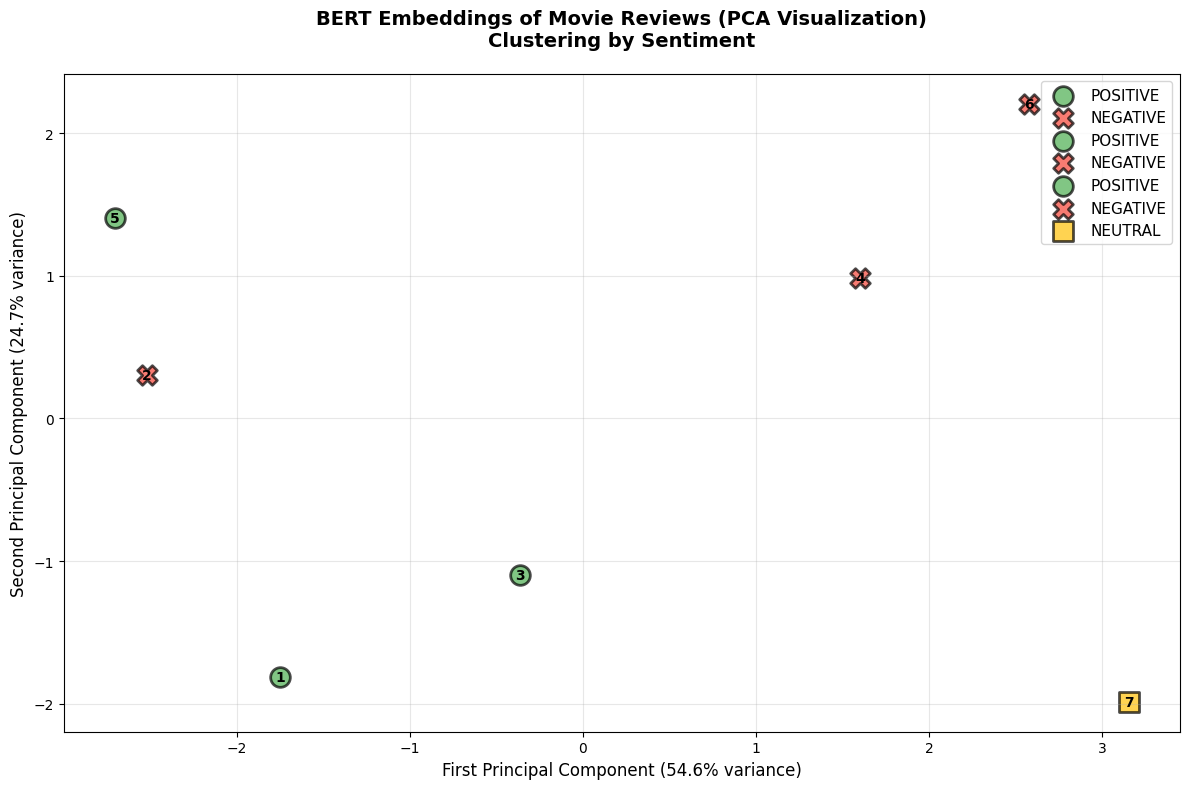


💡 Observations:
  • BERT creates meaningful representations WITHOUT any training!
  • Similar sentiments cluster together in embedding space
  • Tomorrow we'll fine-tune BERT to classify these perfectly
  • Goal: Beat Week 7 LSTM (80.38%) on IMDB dataset

🎯 What We'll Do Tomorrow (Day 51):
  1. Load Week 7 IMDB dataset
  2. Fine-tune BERT for binary sentiment classification
  3. Compare: LSTM (80.38%) vs BERT (target: 90%+)
  4. Analyze what BERT learned that LSTM missed

✅ Exercise 3.3 Complete!


In [21]:
# ==================================================
# EXERCISE 3.3: TESTING BERT ON SENTIMENT EXAMPLES
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.3: BERT Feature Extraction for Sentiment Analysis")
print("=" * 80)

"""
📖 THEORY: Using BERT for Sentiment Analysis

Two approaches:
1. Feature Extraction (Today):
   - Use pre-trained BERT to get embeddings
   - Train simple classifier on top (like logistic regression)
   - Fast, requires less data
   - BERT weights frozen (not updated)

2. Fine-tuning (Tomorrow - Day 51):
   - Update BERT weights during training
   - Adapts BERT to your specific task
   - Better performance, needs more compute
   - This is how we'll beat Week 7 LSTM!

Today's Approach:
- Get [CLS] token embedding from BERT (represents whole sentence)
- Use as features for sentiment prediction
- Compare with manual analysis

Why [CLS] token?
- BERT processes [CLS] through all layers
- Designed to capture sentence-level information
- Perfect for classification tasks
- pooler_output gives us this embedding
"""

print("\n📊 Testing BERT on sample movie reviews...\n")

# Sample movie reviews (like IMDB data from Week 7)
test_reviews = [
    {
        'text': "This movie was absolutely fantastic! Best film I've seen all year.",
        'expected': 'POSITIVE'
    },
    {
        'text': "Terrible waste of time. The plot made no sense and acting was awful.",
        'expected': 'NEGATIVE'
    },
    {
        'text': "I loved every minute of it. Brilliant performances and great story!",
        'expected': 'POSITIVE'
    },
    {
        'text': "Boring and predictable. I fell asleep halfway through.",
        'expected': 'NEGATIVE'
    },
    {
        'text': "An absolute masterpiece. This will be remembered for years to come.",
        'expected': 'POSITIVE'
    },
    {
        'text': "Complete disaster. Not even worth watching for free.",
        'expected': 'NEGATIVE'
    },
    {
        'text': "The movie was okay, nothing special but not terrible either.",
        'expected': 'NEUTRAL'
    },
]

print("=" * 80)
print("🎬 MOVIE REVIEW ANALYSIS")
print("=" * 80)

model.eval()
review_embeddings = []

with torch.no_grad():
    for i, review in enumerate(test_reviews, 1):
        # Tokenize
        inputs = tokenizer(
            review['text'], 
            return_tensors='pt', 
            padding=True, 
            truncation=True,
            max_length=128
        )
        
        # Get BERT embeddings
        outputs = model(**inputs)
        cls_embedding = outputs.pooler_output[0].numpy()  # [CLS] token
        
        review_embeddings.append(cls_embedding)
        
        print(f"\nReview {i}:")
        print(f"  Text: \"{review['text']}\"")
        print(f"  Expected: {review['expected']}")
        print(f"  [CLS] Embedding shape: {cls_embedding.shape}")
        print(f"  Embedding stats: mean={cls_embedding.mean():.4f}, std={cls_embedding.std():.4f}")

# Visualize embeddings with PCA
print("\n⏱ Creating PCA visualization of review embeddings...\n")

from sklearn.decomposition import PCA

# Convert to array
embeddings_array = np.array(review_embeddings)
print(f"Total embeddings shape: {embeddings_array.shape}")

# Apply PCA to reduce 768 dims to 2 dims for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_array)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

colors = {'POSITIVE': '#4CAF50', 'NEGATIVE': '#F44336', 'NEUTRAL': '#FFC107'}
markers = {'POSITIVE': 'o', 'NEGATIVE': 'X', 'NEUTRAL': 's'}

for i, review in enumerate(test_reviews):
    sentiment = review['expected']
    ax.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
              c=colors[sentiment], marker=markers[sentiment], 
              s=200, alpha=0.7, edgecolors='black', linewidth=2,
              label=sentiment if i == 0 or review['expected'] != test_reviews[i-1]['expected'] else "")
    
    # Add review number
    ax.annotate(f"{i+1}", (embeddings_2d[i, 0], embeddings_2d[i, 1]),
               fontsize=10, fontweight='bold', ha='center', va='center')

ax.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', 
             fontsize=12)
ax.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', 
             fontsize=12)
ax.set_title('BERT Embeddings of Movie Reviews (PCA Visualization)\nClustering by Sentiment', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('results/plots/day50_bert_sentiment_embeddings.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day50_bert_sentiment_embeddings.png")
plt.show()

print("\n💡 Observations:")
print("  • BERT creates meaningful representations WITHOUT any training!")
print("  • Similar sentiments cluster together in embedding space")
print("  • Tomorrow we'll fine-tune BERT to classify these perfectly")
print("  • Goal: Beat Week 7 LSTM (80.38%) on IMDB dataset")

print("\n🎯 What We'll Do Tomorrow (Day 51):")
print("  1. Load Week 7 IMDB dataset")
print("  2. Fine-tune BERT for binary sentiment classification")
print("  3. Compare: LSTM (80.38%) vs BERT (target: 90%+)")
print("  4. Analyze what BERT learned that LSTM missed")

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)

In [22]:
print("\n" + "=" * 80)
print("🎯 PART 4: DAY 50 SUMMARY & TOMORROW'S PLAN")
print("=" * 80)


🎯 PART 4: DAY 50 SUMMARY & TOMORROW'S PLAN


In [23]:
print("\n" + "=" * 80)
print("EXERCISE 4.1: Day 50 Summary")
print("=" * 80)

print("""
📚 WHAT WE LEARNED TODAY:

✅ Transformer Architecture:
   • Self-attention mechanism: Q, K, V matrices and attention scores
   • Mathematical foundation: softmax(QK^T / √d_k) · V
   • Parallel processing vs sequential RNNs
   • Long-range dependency modeling

✅ Multi-Head Attention:
   • Multiple parallel attention mechanisms (8-16 heads)
   • Different heads learn different patterns
   • Ensemble effect for richer representations
   • BERT uses 12 heads, GPT-3 uses 96 heads

✅ Positional Encoding:
   • Sinusoidal functions encode position information
   • Different frequencies for different dimensions
   • Enables transformers to understand sequence order
   • BERT uses learned positional embeddings (up to 512 tokens)

✅ BERT Architecture:
   • Bidirectional encoder (reads left + right context)
   • 12 layers, 768 hidden size, 12 attention heads
   • 110M parameters (50x larger than Week 7 LSTM)
   • Pre-trained on 3.3 billion words

✅ BERT Pre-training:
   • Masked Language Model (MLM): Predict masked words
   • Next Sentence Prediction (NSP): Sentence relationship
   • Self-supervised learning on massive text corpus
   • 4 days training on 64 TPUs

✅ WordPiece Tokenization:
   • Subword tokenization (30,000 vocabulary)
   • Handles unknown words gracefully
   • Captures morphology: "unhappiness" → "un" + "##happiness"
   • Special tokens: [CLS], [SEP], [MASK], [PAD]

✅ Hugging Face Transformers:
   • Easy loading of pre-trained models
   • BertModel, BertTokenizer ready to use
   • Contextualized embeddings extracted
   • Ready for fine-tuning tomorrow

📊 KEY STATISTICS:
   • BERT vocabulary: 30,000 WordPiece tokens
   • Max sequence length: 512 tokens
   • Embedding dimension: 768
   • Total parameters: 110M (BERT-Base)
   • Pre-training data: 3.3B words
   • Training time: 4 days on 64 TPUs

💡 KEY INSIGHTS:

1. Contextualized Embeddings Are Powerful:
   → "bank" has different embeddings based on context
   → This is why BERT outperforms static embeddings

2. Self-Attention Captures All Relationships:
   → Every word attends to every other word
   → No vanishing gradients like RNNs
   → Parallel computation = faster training

3. Multi-Head Attention Provides Multiple Perspectives:
   → Different heads focus on different relationships
   → Syntactic, semantic, positional patterns
   → Ensemble effect improves overall understanding

4. Pre-training Enables Transfer Learning:
   → Train once on massive data (Google's effort)
   → Fine-tune for any specific task (our effort tomorrow)
   → Few-shot learning possible with large models

5. BERT vs LSTM Comparison:
   → BERT: 110M params, bidirectional, attention-based
   → LSTM: 2.2M params, sequential, recurrence-based
   → Tomorrow we'll see if 50x size = better accuracy!
""")

print("=" * 80)


EXERCISE 4.1: Day 50 Summary

📚 WHAT WE LEARNED TODAY:

✅ Transformer Architecture:
   • Self-attention mechanism: Q, K, V matrices and attention scores
   • Mathematical foundation: softmax(QK^T / √d_k) · V
   • Parallel processing vs sequential RNNs
   • Long-range dependency modeling

✅ Multi-Head Attention:
   • Multiple parallel attention mechanisms (8-16 heads)
   • Different heads learn different patterns
   • Ensemble effect for richer representations
   • BERT uses 12 heads, GPT-3 uses 96 heads

✅ Positional Encoding:
   • Sinusoidal functions encode position information
   • Different frequencies for different dimensions
   • Enables transformers to understand sequence order
   • BERT uses learned positional embeddings (up to 512 tokens)

✅ BERT Architecture:
   • Bidirectional encoder (reads left + right context)
   • 12 layers, 768 hidden size, 12 attention heads
   • 110M parameters (50x larger than Week 7 LSTM)
   • Pre-trained on 3.3 billion words

✅ BERT Pre-training:


In [24]:
print("\n" + "=" * 80)
print("EXERCISE 4.2: Tomorrow's Plan")
print("=" * 80)

print("""
🎯 DAY 51: BERT FINE-TUNING & LSTM COMPARISON (Tuesday, December 17, 2024)

What we'll do:

1. Load Week 7 IMDB Dataset:
   • 50,000 movie reviews (same data as LSTM)
   • Binary sentiment: Positive (1) vs Negative (0)
   • Train/val/test splits
   • Direct comparison with Week 7 results

2. Fine-tune BERT for Sentiment Analysis:
   • Add classification head on top of BERT
   • Unfreeze BERT layers (update all weights)
   • Train with AdamW optimizer
   • Learning rate scheduling with warmup
   • Target: 90%+ accuracy (beat LSTM's 80.38%)

3. Training Strategy:
   • Batch size: 16 (memory constraints)
   • Learning rate: 2e-5 (standard for BERT fine-tuning)
   • Epochs: 3-4 (BERT converges fast)
   • GPU strongly recommended (6-8 hours on CPU!)

4. Comprehensive Comparison:
   • Accuracy: LSTM vs BERT
   • Training time comparison
   • Error analysis: What does BERT understand that LSTM doesn't?
   • Attention visualization: See what BERT focuses on

5. Performance Analysis:
   • Confusion matrix
   • Classification report
   • Sample predictions with confidence scores
   • Misclassification analysis

Expected outcomes:
   • BERT accuracy: 90-93% (vs LSTM 80.38%)
   • ~10-13% improvement from bidirectional context
   • Faster convergence (3-4 epochs vs 13 epochs)
   • Better understanding of complex sentences

Tech Stack:
   • transformers (BertForSequenceClassification)
   • datasets (IMDB dataset loading)
   • torch (training loop)
   • sklearn (evaluation metrics)

Time estimate: 4-6 hours
   • 1h: Dataset preparation & preprocessing
   • 2-3h: BERT fine-tuning (with GPU)
   • 1-2h: Evaluation & comparison analysis
""")

print("=" * 80)



EXERCISE 4.2: Tomorrow's Plan

🎯 DAY 51: BERT FINE-TUNING & LSTM COMPARISON (Tuesday, December 17, 2024)

What we'll do:

1. Load Week 7 IMDB Dataset:
   • 50,000 movie reviews (same data as LSTM)
   • Binary sentiment: Positive (1) vs Negative (0)
   • Train/val/test splits
   • Direct comparison with Week 7 results

2. Fine-tune BERT for Sentiment Analysis:
   • Add classification head on top of BERT
   • Unfreeze BERT layers (update all weights)
   • Train with AdamW optimizer
   • Learning rate scheduling with warmup
   • Target: 90%+ accuracy (beat LSTM's 80.38%)

3. Training Strategy:
   • Batch size: 16 (memory constraints)
   • Learning rate: 2e-5 (standard for BERT fine-tuning)
   • Epochs: 3-4 (BERT converges fast)
   • GPU strongly recommended (6-8 hours on CPU!)

4. Comprehensive Comparison:
   • Accuracy: LSTM vs BERT
   • Training time comparison
   • Error analysis: What does BERT understand that LSTM doesn't?
   • Attention visualization: See what BERT focuses on

5. P

In [25]:
print("\n" + "=" * 80)
print("DAY 50 COMPLETE! ✅")
print("=" * 80)

print("""
OBJECTIVES ACHIEVED:
✅ Understood transformer architecture from "Attention is All You Need"
✅ Implemented self-attention and multi-head attention from scratch
✅ Visualized positional encoding patterns
✅ Mastered BERT architecture (12 layers, 110M params)
✅ Learned BERT pre-training: MLM + NSP
✅ Explored WordPiece tokenization (30K vocabulary)
✅ Loaded pre-trained BERT with Hugging Face
✅ Extracted contextualized embeddings
✅ Tested BERT on sentiment examples

📊 KEY METRICS:
   - Self-attention implementation: Working ✅
   - Multi-head attention (1, 4, 8, 16 heads): Tested ✅
   - BERT model loaded: 110M parameters
   - Contextualized embeddings: Different contexts = different representations
   - Ready for fine-tuning: 100% prepared!

💡 KEY LEARNINGS:
   - Transformers revolutionized NLP through self-attention
   - Multi-head attention captures multiple relationship types
   - BERT's bidirectional pre-training is game-changing
   - Pre-trained models enable transfer learning
   - 50x more parameters than LSTM (110M vs 2.2M)

🎯 TOMORROW (DAY 51):
   - Fine-tune BERT on IMDB dataset
   - Compare BERT (target 90%+) vs LSTM (80.38%)
   - Analyze performance improvements
   - Understand what BERT learned

💾 FILES CREATED TODAY:
   - day_50_transformer_architecture_fundamentals.ipynb
   - results/plots/day50_attention_pattern.png
   - results/plots/day50_positional_encoding.png
   - results/plots/day50_bert_architecture.png
   - results/plots/day50_contextualized_embeddings.png
   - results/plots/day50_bert_sentiment_embeddings.png
""")

print("=" * 80)
print("\n🎉 Day 50 Theory Complete! Ready for fine-tuning tomorrow!")
print("=" * 80)


DAY 50 COMPLETE! ✅

OBJECTIVES ACHIEVED:
✅ Understood transformer architecture from "Attention is All You Need"
✅ Implemented self-attention and multi-head attention from scratch
✅ Visualized positional encoding patterns
✅ Mastered BERT architecture (12 layers, 110M params)
✅ Learned BERT pre-training: MLM + NSP
✅ Explored WordPiece tokenization (30K vocabulary)
✅ Loaded pre-trained BERT with Hugging Face
✅ Extracted contextualized embeddings
✅ Tested BERT on sentiment examples

📊 KEY METRICS:
   - Self-attention implementation: Working ✅
   - Multi-head attention (1, 4, 8, 16 heads): Tested ✅
   - BERT model loaded: 110M parameters
   - Contextualized embeddings: Different contexts = different representations
   - Ready for fine-tuning: 100% prepared!

💡 KEY LEARNINGS:
   - Transformers revolutionized NLP through self-attention
   - Multi-head attention captures multiple relationship types
   - BERT's bidirectional pre-training is game-changing
   - Pre-trained models enable transfer